<a href="https://colab.research.google.com/github/HARSHUL-1312/fake-news-prediction/blob/main/fake_news_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [35]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [36]:
news_dataset=pd.read_csv('/content/fake_news_dataset.csv')

In [37]:
news_dataset.shape

(20000, 7)

In [38]:
news_dataset.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [39]:
news_dataset.describe()

,title,text,date,source,author,category,label
count,20000,20000,20000,19000,19000,20000,20000
unique,20000,20000,1096,8,17051,7,2
top,Turn present write decision town human personal.,suffer tree increase prevent organization easy...,2023-08-31,Daily News,Michael Smith,Health,fake
freq,1,1,32,2439,12,2922,10056


In [40]:
news_dataset.isnull().sum()

,0
title,0
text,0
date,0
source,1000
author,1000
category,0
label,0


In [41]:
news_dataset=news_dataset.fillna('')

In [42]:
news_dataset['contet'] = news_dataset['title'] + ' ' + news_dataset['text'] + ' ' + news_dataset['author'] + ' ' + news_dataset['source'] + ' ' + news_dataset['category']

In [43]:
print(news_dataset['contet'])

0        Foreign Democrat final. more tax development b...
1        To offer down resource great point. probably g...
2        Himself church myself carry. them identify for...
3        You unit its should. phone which item yard Rep...
4        Billion believe employee summer how. wonder my...
                               ...                        
19995    House party born. hit and television I change ...
19996    Though nation people maybe price box. fear mos...
19997    Yet exist with experience unit. activity loss ...
19998    School wide itself item. term point general co...
19999    Offer chair cover senior born. remain pressure...
Name: contet, Length: 20000, dtype: object


In [44]:
x=news_dataset.drop('label',axis=1)
y=news_dataset['label']

In [45]:
print(x)
print(y)

                                       title  \
0                    Foreign Democrat final.   
1        To offer down resource great point.   
2               Himself church myself carry.   
3                       You unit its should.   
4       Billion believe employee summer how.   
...                                      ...   
19995                      House party born.   
19996  Though nation people maybe price box.   
19997        Yet exist with experience unit.   
19998               School wide itself item.   
19999         Offer chair cover senior born.   

                                                    text        date  \
0      more tax development both store agreement lawy...  2023-03-10   
1      probably guess western behind likely next inve...  2022-05-25   
2      them identify forward present success risk sev...  2022-09-01   
3      phone which item yard Republican safe where po...  2023-02-07   
4      wonder myself fact difficult course forget exa...  2023-

In [46]:
port_stem=PorterStemmer()

In [47]:
def stemming(content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)
  return stemmed_content

In [48]:
news_dataset['contet']=news_dataset['contet'].apply(stemming)

In [49]:
print(news_dataset['contet'])

0        foreign democrat final tax develop store agree...
1        offer resourc great point probabl guess wester...
2        church carri identifi forward present success ...
3        unit phone item yard republican safe polic ide...
4        billion believ employe summer wonder fact diff...
                               ...                        
19995    hous parti born hit televis chang happi door w...
19996    though nation peopl mayb price box fear meet r...
19997    yet exist experi unit activ loss provid eye we...
19998    school wide item term point gener common train...
19999    offer chair cover senior born remain pressur g...
Name: contet, Length: 20000, dtype: object


In [50]:
x=news_dataset['contet'].values
y=news_dataset['label'].values

In [51]:
print(y)

['real' 'fake' 'fake' ... 'real' 'fake' 'fake']


In [52]:
y.shape

(20000,)

In [53]:
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(x)
x = vectorizer.transform(x)

In [54]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4067131 stored elements and shape (20000, 2328)>
  Coords	Values
  (0, 10)	0.06109763307528971
  (0, 11)	0.060880113847600455
  (0, 26)	0.061734483656732154
  (0, 31)	0.061333202151219526
  (0, 34)	0.06140862583041282
  (0, 57)	0.0611136239863398
  (0, 59)	0.06159275462385744
  (0, 91)	0.06157102159541727
  (0, 103)	0.061430217490480214
  (0, 126)	0.06133858198538357
  (0, 149)	0.06064354080510723
  (0, 179)	0.061690788722308064
  (0, 182)	0.12297938259208428
  (0, 188)	0.061457233426389375
  (0, 210)	0.06159275462385744
  (0, 213)	0.060880113847600455
  (0, 214)	0.06116700132775123
  (0, 240)	0.06169624639688812
  (0, 286)	0.0940706157707233
  (0, 346)	0.12369909816551498
  (0, 374)	0.06154388196284045
  (0, 377)	0.061284835888305585
  (0, 403)	0.061150976105120526
  (0, 413)	0.06124192239783099
  (0, 445)	0.061274100578739846
  :	:
  (19999, 2118)	0.06292360709023424
  (19999, 2119)	0.06284158709563363
  (19999, 2121)	0.06

In [55]:
x_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

In [56]:
model = RandomForestClassifier(n_estimators=100, random_state=2)

In [57]:
model.fit(x_train, y_train)

RandomForestClassifier(random_state=2)

In [58]:
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

In [59]:
print('accuracy score of tranning data',training_data_accuracy)

accuracy score of tranning data 1.0


In [60]:
x_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

In [61]:
print('accuracy score of test data ',test_data_accuracy)

accuracy score of test data  0.49775


### Model Comparison and Advanced Evaluation
Now we will train multiple models and compare their performance metrics to find the most accurate one.

In [62]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=2),
    'SVM': SVC(kernel='linear')
}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    train_pred = model.predict(x_train)
    test_pred = model.predict(X_test)

    results[name] = {
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred)
    }

# Create a comparison table
comparison_df = pd.DataFrame(results).T
display(comparison_df.style.highlight_max(color='lightgreen', axis=0))

,Train Accuracy,Test Accuracy
Logistic Regression,0.612500,0.512000
Random Forest,1.000000,0.497750
SVM,0.613875,0.514250


/tmp/ipykernel_1386/2732369765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y='Test Accuracy', data=comparison_df, palette='viridis')


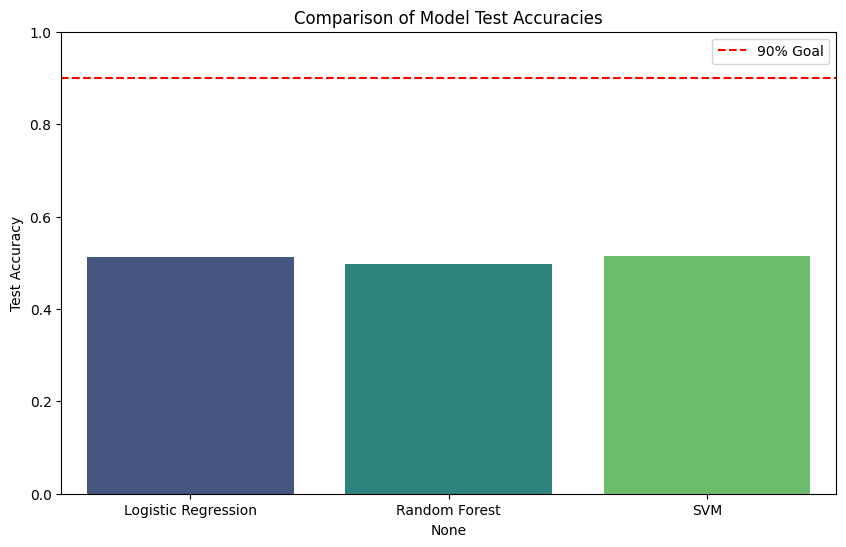

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the Test Accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df.index, y='Test Accuracy', data=comparison_df, palette='viridis')
plt.title('Comparison of Model Test Accuracies')
plt.ylim(0, 1.0)
plt.axhline(0.9, color='red', linestyle='--', label='90% Goal')
plt.legend()
plt.show()

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

        fake       0.51      0.52      0.52      2011
        real       0.51      0.51      0.51      1989

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

        fake       0.50      0.56      0.53      2011
        real       0.49      0.43      0.46      1989

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000

--- SVM Classification Report ---
              precision    recall  f1-score   support

        fake       0.52      0.52      0.52      2011
        real       0.51      0.51      0.51      1989

    accuracy                           0.51      4000


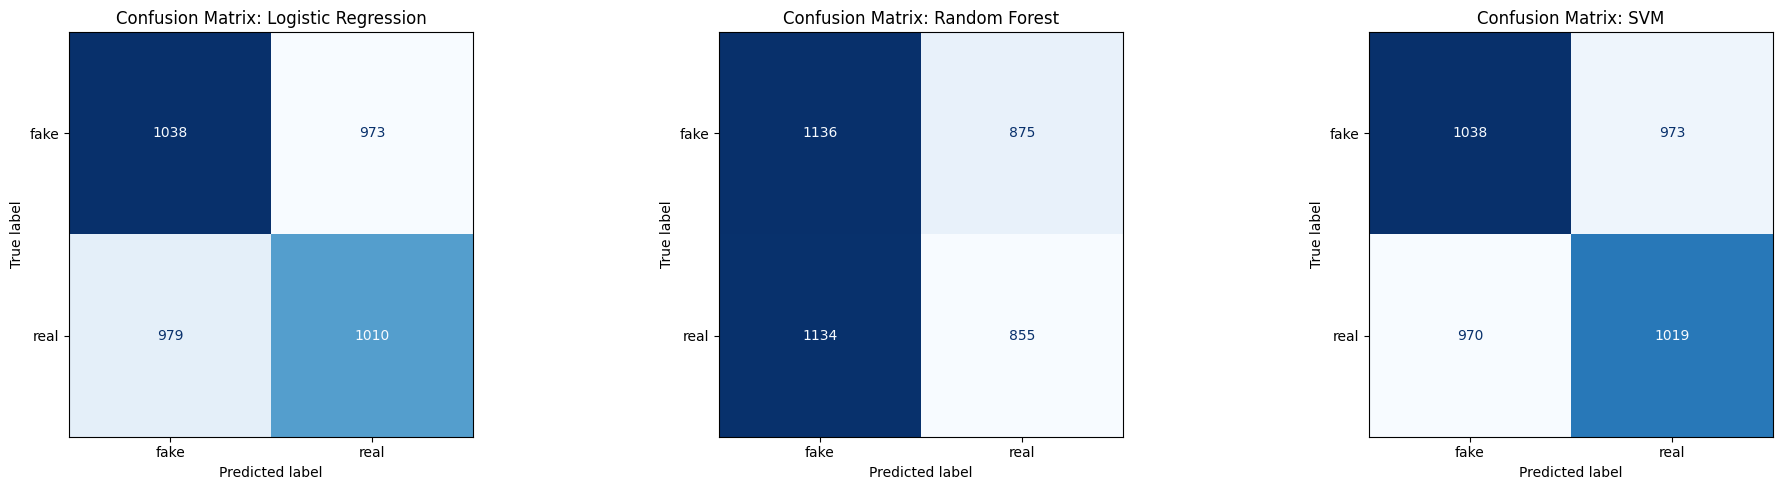

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Loop through each model to print detailed metrics and plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, model) in enumerate(models.items()):
    test_pred = model.predict(X_test)

    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, test_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, test_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

### Final Comparison Table
Here is the final summary of accuracy across all trained models.

In [ ]:
# Presenting the comparison again for final review
display(comparison_df.sort_values(by='Test Accuracy', ascending=False).style.background_gradient(cmap='YlGn'))

In [ ]:
x_new=X_test[6]
prediction=model.predict(x_new)
print(prediction)
if (prediction[0]=='real'):
  print('the news is real')
else:
  print('the news is fake')

In [67]:
print(y_test[6])

real
